# KNN_SVM_프로모션_효율예측분석

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

In [3]:
mem = pd.read_csv("./data/member.csv")
tran = pd.read_csv("./data/transaction.csv")

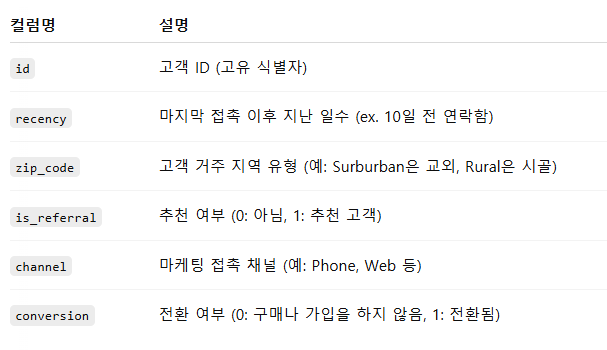

* 쇼핑몰 고객 데이터, 프로모션 쿠폰을 발행하고 사용 여부 데이터 수집
* mem : 고객id, 최근 방문일, 사는 지역, 추천여부, 주요접속채널, 쿠폰사용여부(target)
* tran : 고객id, 구매수량, 총 구매금액
* 전통적 마케팅 분석 방법 RFM 기법을 활용해서 고객 데이터에서 파생변수 생성 후 분석
* R: Recency: 현재일 - 최근 구매일
* F: Frequency: 구매빈도
* M: Monetary: 구매금액
* 종속변수: conversion => 고객이 프로모션에 반응 했는가? 1 = yes, 0 = no

## 구매빈도와 구매금액은 파생변수로 직접 구해야 한다
F: Frequency: 구매빈도<br>
M: Monetary: 구매금액

In [7]:
mem

,id,recency,zip_code,is_referral,channel,conversion
0,906145,10,Surburban,0,Phone,0
1,184478,6,Rural,1,Web,0
2,394235,7,Surburban,1,Web,0
3,130152,9,Rural,1,Web,0
4,940352,2,Urban,0,Web,0
...,...,...,...,...,...,...
63995,838295,10,Urban,0,Web,0
63996,547316,5,Urban,1,Phone,0
63997,131575,6,Urban,1,Phone,0
63998,603659,1,Surburban,1,Multichannel,0


In [4]:
mem.head(2)

,id,recency,zip_code,is_referral,channel,conversion
0,906145,10,Surburban,0,Phone,0
1,184478,6,Rural,1,Web,0


In [8]:
tran

,id,num_item,total_amount
0,906145,5,34000
1,906145,1,27000
2,906145,4,33000
3,184478,4,29000
4,394235,4,33000
...,...,...,...
196831,536246,5,24000
196832,927617,5,26000
196833,927617,3,22000
196834,927617,3,18000


In [6]:
tran.head(2)

,id,num_item,total_amount
0,906145,5,34000
1,906145,1,27000


In [10]:
data = pd.merge(mem, tran, on='id')

In [11]:
data

,id,recency,zip_code,is_referral,channel,conversion,num_item,total_amount
0,906145,10,Surburban,0,Phone,0,5,34000
1,906145,10,Surburban,0,Phone,0,1,27000
2,906145,10,Surburban,0,Phone,0,4,33000
3,184478,6,Rural,1,Web,0,4,29000
4,394235,7,Surburban,1,Web,0,4,33000
...,...,...,...,...,...,...,...,...
196831,254229,1,Surburban,0,Web,0,3,33000
196832,254229,1,Surburban,0,Web,0,1,18000
196833,254229,1,Surburban,0,Web,0,3,24000
196834,254229,1,Surburban,0,Web,0,5,14000


In [13]:
data.columns

Index(['id', 'recency', 'zip_code', 'is_referral', 'channel', 'conversion',
       'num_item', 'total_amount'],
      dtype='object')

In [12]:
data.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196836 entries, 0 to 196835
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            196836 non-null  int64 
 1   recency       196836 non-null  int64 
 2   zip_code      196836 non-null  object
 3   is_referral   196836 non-null  int64 
 4   channel       196836 non-null  object
 5   conversion    196836 non-null  int64 
 6   num_item      196836 non-null  int64 
 7   total_amount  196836 non-null  int64 
dtypes: int64(6), object(2)
memory usage: 12.0+ MB


In [18]:
data.isna().sum()

id              0
recency         0
zip_code        0
is_referral     0
channel         0
conversion      0
num_item        0
total_amount    0
dtype: int64

In [22]:
data.duplicated().sum()

np.int64(1882)

In [16]:
data.nunique()

id              64000
recency            12
zip_code            3
is_referral         2
channel             3
conversion          2
num_item            6
total_amount       31
dtype: int64

In [23]:
# 문자형, 숫자형 DF 분류하기
obj_cols = data.select_dtypes(include='object')
num_cols = data.select_dtypes(exclude='object')

In [24]:
for col in obj_cols:
    print("=" * 30, col, "=" * 30)
    print("nunique: ", obj_cols[col].nunique(), end="\n\n")
    print(obj_cols[col].value_counts(), end="\n\n")
    print(data[[col, 'conversion']].groupby(col).mean().sort_values(by='conversion', ascending=False), end="\n\n")

============================== zip_code ==============================
nunique:  3

zip_code
Surburban    88300
Urban        78801
Rural        29735
Name: count, dtype: int64

           conversion
zip_code             
Rural        0.210964
Surburban    0.159422
Urban        0.157206

============================== channel ==============================
nunique:  3

channel
Web             86934
Phone           86121
Multichannel    23781
Name: count, dtype: int64

              conversion
channel                 
Multichannel    0.195871
Web             0.180447
Phone           0.143902



In [43]:
data['frequency'] = data.groupby('id')['id'].transform(lambda x: len(x))

In [44]:
data['monetary'] = data.groupby('id')['total_amount'].transform(lambda x: x.sum()).sort_values()

In [45]:
data

,id,recency,zip_code,is_referral,channel,conversion,num_item,total_amount,frequency,monetary
0,906145,10,Surburban,0,Phone,0,5,34000,3,94000
1,906145,10,Surburban,0,Phone,0,1,27000,3,94000
2,906145,10,Surburban,0,Phone,0,4,33000,3,94000
3,184478,6,Rural,1,Web,0,4,29000,1,29000
4,394235,7,Surburban,1,Web,0,4,33000,2,41000
...,...,...,...,...,...,...,...,...,...,...
196831,254229,1,Surburban,0,Web,0,3,33000,5,122000
196832,254229,1,Surburban,0,Web,0,1,18000,5,122000
196833,254229,1,Surburban,0,Web,0,3,24000,5,122000
196834,254229,1,Surburban,0,Web,0,5,14000,5,122000


In [47]:
data.describe()

,id,recency,is_referral,conversion,num_item,total_amount,frequency,monetary
count,196836.000000,196836.000000,196836.000000,196836.000000,196836.000000,196836.000000,196836.000000,196836.000000
mean,550557.552932,5.753739,0.501483,0.166321,3.078365,21837.102969,3.698551,80826.215733
std,259254.795613,3.508775,0.499999,0.372370,1.478408,8218.005565,1.219392,31097.295838
min,100001.000000,1.000000,0.000000,0.000000,1.000000,8000.000000,1.000000,8000.000000
25%,326719.000000,2.000000,0.000000,0.000000,2.000000,15000.000000,3.000000,58000.000000
50%,550918.000000,5.000000,1.000000,0.000000,3.000000,22000.000000,4.000000,83000.000000
75%,774916.000000,9.000000,1.000000,0.000000,4.000000,29000.000000,5.000000,104000.000000
max,999997.000000,12.000000,1.000000,1.000000,6.000000,38000.000000,5.000000,184000.000000


In [46]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196836 entries, 0 to 196835
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            196836 non-null  int64 
 1   recency       196836 non-null  int64 
 2   zip_code      196836 non-null  object
 3   is_referral   196836 non-null  int64 
 4   channel       196836 non-null  object
 5   conversion    196836 non-null  int64 
 6   num_item      196836 non-null  int64 
 7   total_amount  196836 non-null  int64 
 8   frequency     196836 non-null  int64 
 9   monetary      196836 non-null  int64 
dtypes: int64(8), object(2)
memory usage: 15.0+ MB


In [33]:
data['monetary'].dropna()

100001     52000.0
100008     26000.0
100032     62000.0
100036    129000.0
100070     85000.0
            ...   
196800     29000.0
196801     62000.0
196803     10000.0
196820     55000.0
196823     53000.0
Name: monetary, Length: 6746, dtype: float64

In [102]:
# 문자형, 숫자형 DF 분류하기
obj_cols = data.select_dtypes(include='object')
num_cols = data.select_dtypes(exclude='object')

In [99]:
ratio_result = data[['recency', 'conversion']].groupby('recency').mean().sort_values(by='conversion', ascending=False)
print(ratio_result)
ratio_result[ratio_result['conversion'] > 0.40].index

         conversion
recency            
1          0.218190
2          0.202224
3          0.187919
4          0.168835
5          0.163830
6          0.159345
7          0.151011
8          0.146590
12         0.142200
11         0.135693
9          0.130244
10         0.127223


Index([], dtype='int64', name='recency')

In [100]:
ratio_result = data[['frequency', 'conversion']].groupby('frequency').mean().sort_values(by='conversion', ascending=False)
print(ratio_result)
ratio_result[ratio_result['conversion'] > 0.40].index

           conversion
frequency            
3            0.181765
2            0.178127
5            0.175891
4            0.171859
1            0.000000


Index([], dtype='int64', name='frequency')

In [101]:
ratio_result = data[['monetary', 'conversion']].groupby('monetary').mean().sort_values(by='conversion', ascending=False)
print(ratio_result)
ratio_result[ratio_result['conversion'] > 0.40].index

          conversion
monetary            
183000           1.0
171000           1.0
164000           1.0
167000           1.0
184000           1.0
...              ...
14000            0.0
13000            0.0
12000            0.0
11000            0.0
10000            0.0

[162 rows x 1 columns]


Index([183000, 171000, 164000, 167000, 184000, 157000, 162000, 161000, 165000,
       160000, 159000, 146000, 158000, 147000, 153000, 148000, 163000, 151000,
       149000, 145000, 156000, 143000],
      dtype='int64', name='monetary')

In [105]:
obj_cols.columns

Index([], dtype='object')

In [106]:
num_cols.columns

Index(['id', 'recency', 'is_referral', 'conversion', 'num_item',
       'total_amount', 'frequency', 'monetary', 'zip_code_Surburban',
       'zip_code_Urban', 'channel_Phone', 'channel_Web'],
      dtype='object')

In [ ]:
important_cols = []
for col in obj_cols:
    print("=" * 30, col, "=" * 30)
    print()
    print(col, f'nunique: {obj_cols[col].nunique()}')
    print(obj_cols[col].value_counts())
    print()
    print(data[[col, 'class']].groupby(col).mean().sort_values(by='class', ascending=False))
    ratio_result = data[[col, 'class']].groupby(col).mean().sort_values(by='class', ascending=False)
    important_cols.append(ratio_result[ratio_result['class'] > 0.40].index)
    print()

In [57]:
data['conversion'].value_counts()

conversion
0    164098
1     32738
Name: count, dtype: int64

In [59]:
32738 / 164098 * 100

19.950273616984973

In [66]:
from ydata_profiling import ProfileReport

C:\Users\Admin\miniforge3\envs\fintech\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [107]:
profile = ProfileReport(data, title="Profiling Report")

In [108]:
profile.to_file("conversion_eda.html")

Export report to file: 100%|████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 142.83it/s]


In [72]:
data

,id,recency,zip_code,is_referral,channel,conversion,num_item,total_amount,frequency,monetary
0,906145,10,Surburban,0,Phone,0,5,34000,3,94000
1,906145,10,Surburban,0,Phone,0,1,27000,3,94000
2,906145,10,Surburban,0,Phone,0,4,33000,3,94000
3,184478,6,Rural,1,Web,0,4,29000,1,29000
4,394235,7,Surburban,1,Web,0,4,33000,2,41000
...,...,...,...,...,...,...,...,...,...,...
196831,254229,1,Surburban,0,Web,0,3,33000,5,122000
196832,254229,1,Surburban,0,Web,0,1,18000,5,122000
196833,254229,1,Surburban,0,Web,0,3,24000,5,122000
196834,254229,1,Surburban,0,Web,0,5,14000,5,122000


In [75]:
data = data.drop_duplicates()

In [80]:
data

,id,recency,zip_code,is_referral,channel,conversion,num_item,total_amount,frequency,monetary
0,906145,10,Surburban,0,Phone,0,5,34000,3,94000
1,906145,10,Surburban,0,Phone,0,1,27000,3,94000
2,906145,10,Surburban,0,Phone,0,4,33000,3,94000
3,184478,6,Rural,1,Web,0,4,29000,1,29000
4,394235,7,Surburban,1,Web,0,4,33000,2,41000
...,...,...,...,...,...,...,...,...,...,...
196831,254229,1,Surburban,0,Web,0,3,33000,5,122000
196832,254229,1,Surburban,0,Web,0,1,18000,5,122000
196833,254229,1,Surburban,0,Web,0,3,24000,5,122000
196834,254229,1,Surburban,0,Web,0,5,14000,5,122000


In [83]:
data = pd.get_dummies(data, drop_first=True)

In [84]:
data

,id,recency,is_referral,conversion,num_item,total_amount,frequency,monetary,zip_code_Surburban,zip_code_Urban,channel_Phone,channel_Web
0,906145,10,0,0,5,34000,3,94000,True,False,True,False
1,906145,10,0,0,1,27000,3,94000,True,False,True,False
2,906145,10,0,0,4,33000,3,94000,True,False,True,False
3,184478,6,1,0,4,29000,1,29000,False,False,False,True
4,394235,7,1,0,4,33000,2,41000,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...
196831,254229,1,0,0,3,33000,5,122000,True,False,False,True
196832,254229,1,0,0,1,18000,5,122000,True,False,False,True
196833,254229,1,0,0,3,24000,5,122000,True,False,False,True
196834,254229,1,0,0,5,14000,5,122000,True,False,False,True


In [81]:
from sklearn.model_selection import train_test_split

In [86]:
X = data.drop('conversion', axis = 1)

In [87]:
y = data['conversion']

In [88]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, stratify=y, random_state=10)

In [89]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

In [90]:
dtc = DecisionTreeClassifier(max_depth=9, random_state=10)
dtc.fit(X_train, y_train)
pred = dtc.predict(X_test)
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.87      1.00      0.93     64994
           1       0.99      0.25      0.40     12988

    accuracy                           0.88     77982
   macro avg       0.93      0.63      0.67     77982
weighted avg       0.89      0.88      0.84     77982



In [91]:
dtc = DecisionTreeClassifier(class_weight="balanced", random_state=10)
dtc.fit(X_train, y_train)
pred = dtc.predict(X_test)
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.93      0.94      0.93     64994
           1       0.66      0.64      0.65     12988

    accuracy                           0.89     77982
   macro avg       0.80      0.79      0.79     77982
weighted avg       0.88      0.89      0.88     77982



In [ ]:
data.groupby('conversion')[['recency', 'frequency', 'monetary']].mean()


In [109]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

X = data[['recency', 'frequency', 'monetary']]
y = data['conversion']
model = RandomForestClassifier(random_state=42)
model.fit(X, y)
print(classification_report(y, model.predict(X)))

              precision    recall  f1-score   support

           0       0.84      0.99      0.91    162483
           1       0.68      0.09      0.16     32471

    accuracy                           0.84    194954
   macro avg       0.76      0.54      0.53    194954
weighted avg       0.82      0.84      0.79    194954



# KNN, SVM

In [113]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 사용할 피처 선택 (RFM)
X = data.drop('conversion', axis = 1)
y = data['conversion']

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 정규화 (KNN은 거리 기반이므로 꼭 필요!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [114]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 모델 생성
knn = KNeighborsClassifier(n_neighbors=5)  # k 값은 나중에 튜닝해볼 수 있음
knn.fit(X_train_scaled, y_train)

# 예측
pred = knn.predict(X_test_scaled)

# 평가
print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred))

[[47402  1344]
 [ 8154  1587]]
              precision    recall  f1-score   support

           0       0.85      0.97      0.91     48746
           1       0.54      0.16      0.25      9741

    accuracy                           0.84     58487
   macro avg       0.70      0.57      0.58     58487
weighted avg       0.80      0.84      0.80     58487

